Տարածության մեջ տրված է ուղղորդ կորը

$$
\vec r(u) = (u^2 + 1)\vec i + (u^3 + 2)\vec j + (2u - 3)\vec k
$$

որտեղ

$$
0.2 \le u \le 3:
$$

Դիտարկվում է տուփաձև մակերևույթ, որի լայնական հատույթը ուղղանկյուն է`  
$5 \times 2$ չափերով։

Ուղղանկյան կիսաչափերն են`

$$
a = \frac{5}{2} = 2.5, \qquad b = \frac{2}{2} = 1:
$$

Տուփաձև մակերևույթը կառուցվում է չորս նիստերից՝ k = 1,2,3,4: Յուրաքանչյուր նիստի պարամետրական հավասարումը տրվում է հետևյալ կերպ`

$$
\vec{\rho}_k(u,v) =
\vec r(u) +
\frac{d_k}{\cos v}
\left(
\cos(v+\alpha_k)\vec e_0(u) +
\sin(v+\alpha_k)\vec g_0(u)
\right),
$$

որտեղ

$$
\alpha_k = \frac{(k-1)\pi}{2}, \qquad k=1,2,3,4
$$

իսկ $d_k$ արժեքները ընտրվում են հետևյալ կերպ`

$$
d_k =
\begin{cases}
a, & k=1,3, \\
b, & k=2,4.
\end{cases}
$$

Այստեղ $\vec e_0(u)$ և $\vec g_0(u)$վեկտորները որոշվում են ուղղորդ կորի Ֆրենեի եռանիստի միջոցով և հաշվարկվում են հետևյալ բանաձևերով․

$$
\vec e_0(u) =
\frac{(\vec r''(u)\times \vec r'(u))\times \vec r'(u)}
{|\vec r'(u)\times \vec r''(u)|\,|\vec r'(u)|},
$$

$$
\vec g_0(u) =
\frac{\vec r'(u)\times \vec r''(u)}
{|\vec r'(u)\times \vec r''(u)|}:
$$

$v$-ի թույլատրելի միջակայքերը տարբեր են տարբեր նիստերի համար`

$$
v \in \left[-\arctan\!\left(\frac{b}{a}\right),
\arctan\!\left(\frac{b}{a}\right)\right], 
\qquad k=1,3
$$

$$
v \in \left[-\arctan\!\left(\frac{a}{b}\right),
\arctan\!\left(\frac{a}{b}\right)\right], 
\qquad k=2,4
$$
Պահանջվում է կառուցել տուփաձև մակերևույթի $$
\rho_1(u,v), \rho_2(u,v), \rho_3(u,v),\rho_4(u,v)
$$  նիստերի պարամետրական հավասարումները, ինչպես նաև կառուցել տուփաձև մակերևույթը որպես այդ նիստերի միավորում՝


$$
S = \rho_1(u,v) \cup \rho_2(u,v) \cup \rho_3(u,v) \cup \rho_4(u,v),
$$

և իրականացնել դրանց գրաֆիկական պատկերումը: 

In [1]:
import numpy as np
import sympy as sp
import plotly.graph_objects as go

In [2]:
u, v = sp.symbols('u v', real=True)

r_u = sp.Matrix([
    u**2 + 1,
    u**3 + 2,
    2*u - 3
])

r_prime = sp.diff(r_u, u)
r_double_prime = sp.diff(r_prime, u)

In [3]:
cross_vec = r_prime.cross(r_double_prime)
norm_cross = sp.sqrt(cross_vec.dot(cross_vec))
g0_u = sp.simplify(cross_vec / norm_cross)

numerator_e0 = cross_vec.cross(r_prime)
norm_r_prime = sp.sqrt(r_prime.dot(r_prime))
e0_u = sp.simplify(numerator_e0 / (norm_cross * norm_r_prime))

In [4]:
a = sp.Rational(5, 2)
b = sp.Integer(1)

faces_data = {
    1: {
        "d": a,
        "alpha": 0,
        "vmin": -sp.atan(sp.Rational(1, 2.5)),
        "vmax":  sp.atan(sp.Rational(1, 2.5)),
    },
    2: {
        "d": b,
        "alpha": sp.pi / 2,
        "vmin": -sp.atan(sp.Rational(5, 2)),
        "vmax":  sp.atan(sp.Rational(5, 2)),
    },
    3: {
        "d": a,
        "alpha": sp.pi,
        "vmin": -sp.atan(sp.Rational(1, 2.5)),
        "vmax":  sp.atan(sp.Rational(1, 2.5)),
    },
    4: {
        "d": b,
        "alpha": -sp.pi / 2,
        "vmin": -sp.atan(sp.Rational(5, 2)),
        "vmax":  sp.atan(sp.Rational(5, 2)),
    }
}

In [5]:
def rho_expr(k):
    d = faces_data[k]["d"]
    alpha = faces_data[k]["alpha"]
    return sp.simplify(
        r_u + (d / sp.cos(v)) * (
            sp.cos(alpha + v) * e0_u +
            sp.sin(alpha + v) * g0_u
        )
    )

rho_list = [rho_expr(k) for k in range(1, 5)]

In [6]:
print("r(u) =")
sp.pprint(r_u)

print("\nr'(u) =")
sp.pprint(r_prime)

print("\nr''(u) =")
sp.pprint(r_double_prime)

print("\ng₀(u) =")
sp.pprint(g0_u)

print("\ne₀(u) =")
sp.pprint(e0_u)

for i, rho in enumerate(rho_list, start=1):
    print(f"\nρ_{i}(u,v) =")
    sp.pprint(rho)

r(u) =
⎡ 2     ⎤
⎢u  + 1 ⎥
⎢       ⎥
⎢ 3     ⎥
⎢u  + 2 ⎥
⎢       ⎥
⎣2⋅u - 3⎦

r'(u) =
⎡2⋅u ⎤
⎢    ⎥
⎢   2⎥
⎢3⋅u ⎥
⎢    ⎥
⎣ 2  ⎦

r''(u) =
⎡ 2 ⎤
⎢   ⎥
⎢6⋅u⎥
⎢   ⎥
⎣ 0 ⎦

g₀(u) =
⎡        -6⋅u         ⎤
⎢─────────────────────⎥
⎢   __________________⎥
⎢  ╱    4       2     ⎥
⎢╲╱  9⋅u  + 36⋅u  + 4 ⎥
⎢                     ⎥
⎢          2          ⎥
⎢─────────────────────⎥
⎢   __________________⎥
⎢  ╱    4       2     ⎥
⎢╲╱  9⋅u  + 36⋅u  + 4 ⎥
⎢                     ⎥
⎢           2         ⎥
⎢        3⋅u          ⎥
⎢─────────────────────⎥
⎢   __________________⎥
⎢  ╱    4       2     ⎥
⎣╲╱  9⋅u  + 36⋅u  + 4 ⎦

e₀(u) =
⎡                        4                 ⎤
⎢                 4 - 9⋅u                  ⎥
⎢──────────────────────────────────────────⎥
⎢   _______________________________________⎥
⎢  ╱     8        6        4        2      ⎥
⎢╲╱  81⋅u  + 360⋅u  + 216⋅u  + 160⋅u  + 16 ⎥
⎢                                          ⎥
⎢                   ⎛ 2    ⎞               ⎥
⎢               6⋅u⋅⎝u

In [7]:
r_func = sp.lambdify(u, r_u, "numpy")

rho_funcs = [
    (
        sp.lambdify((u, v), rho_k[0], "numpy"),
        sp.lambdify((u, v), rho_k[1], "numpy"),
        sp.lambdify((u, v), rho_k[2], "numpy"),
    )
    for rho_k in rho_list
]

In [8]:
def eval_surface(rho_func, U, V):
    fx, fy, fz = rho_func
    X = np.asarray(fx(U, V), dtype=float)
    Y = np.asarray(fy(U, V), dtype=float)
    Z = np.asarray(fz(U, V), dtype=float)
    return np.stack([X, Y, Z], axis=-1)

def add_curve(fig, curve_x, curve_y, curve_z):
    fig.add_trace(go.Scatter3d(
        x=curve_x,
        y=curve_y,
        z=curve_z,
        mode='lines',
        line=dict(color='black', width=10),
        name='r(u)'
    ))

def add_surface(fig, S, name):
    fig.add_trace(go.Surface(
        x=S[:, :, 0],
        y=S[:, :, 1],
        z=S[:, :, 2],
        showscale=False,
        opacity=0.60,
        name=name
    ))

In [9]:
u_min, u_max = 0.2, 3.0
Nu, Nv = 180, 80
u_vals = np.linspace(u_min, u_max, Nu)

u_curve = np.linspace(u_min, u_max, 400)
curve = np.array(r_func(u_curve), dtype=float).reshape(3, -1).T
curve_x, curve_y, curve_z = curve[:, 0], curve[:, 1], curve[:, 2]

surfaces = []
for k in range(1, 5):
    vmin = float(sp.N(faces_data[k]["vmin"]))
    vmax = float(sp.N(faces_data[k]["vmax"]))
    v_vals = np.linspace(vmin, vmax, Nv)
    U, V = np.meshgrid(u_vals, v_vals, indexing='ij')
    S = eval_surface(rho_funcs[k - 1], U, V)
    surfaces.append(S)

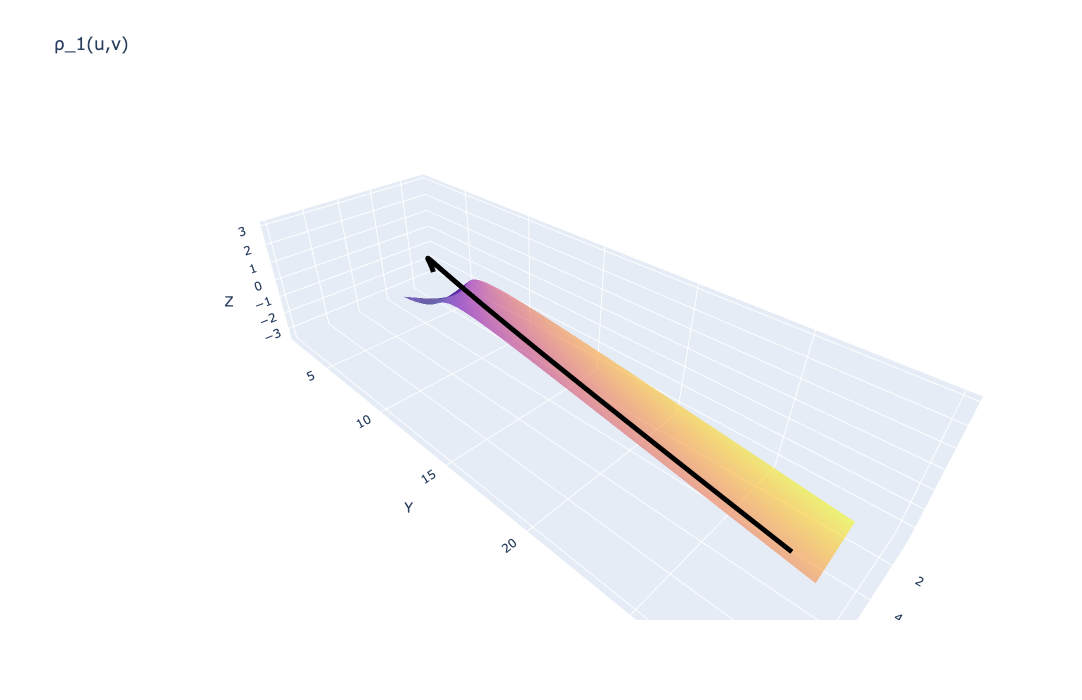

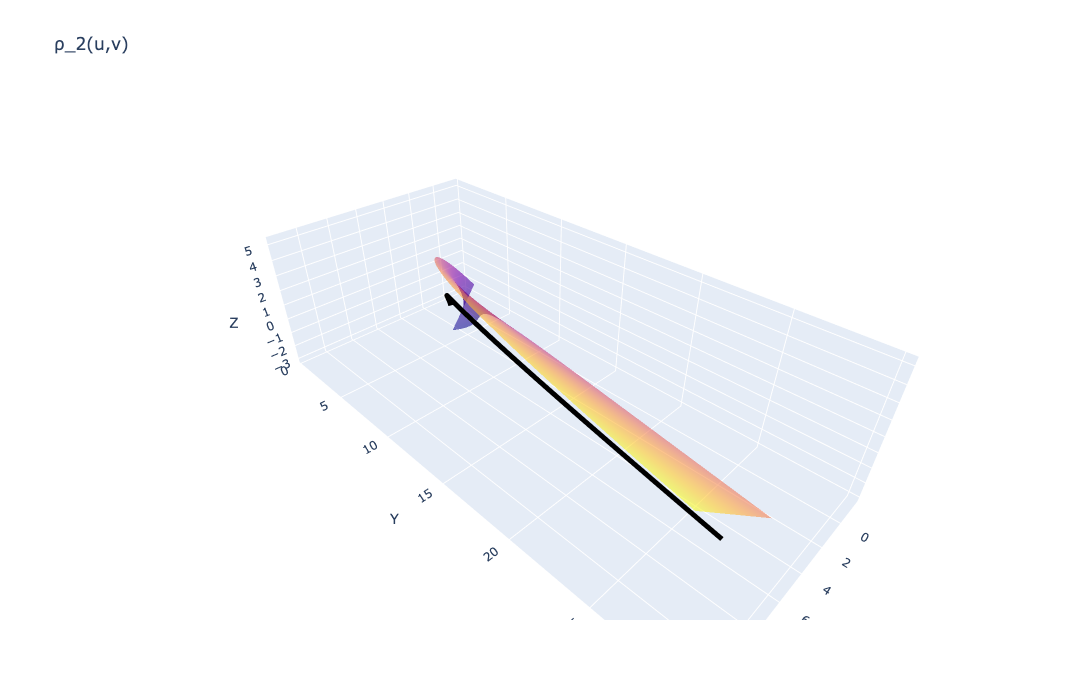

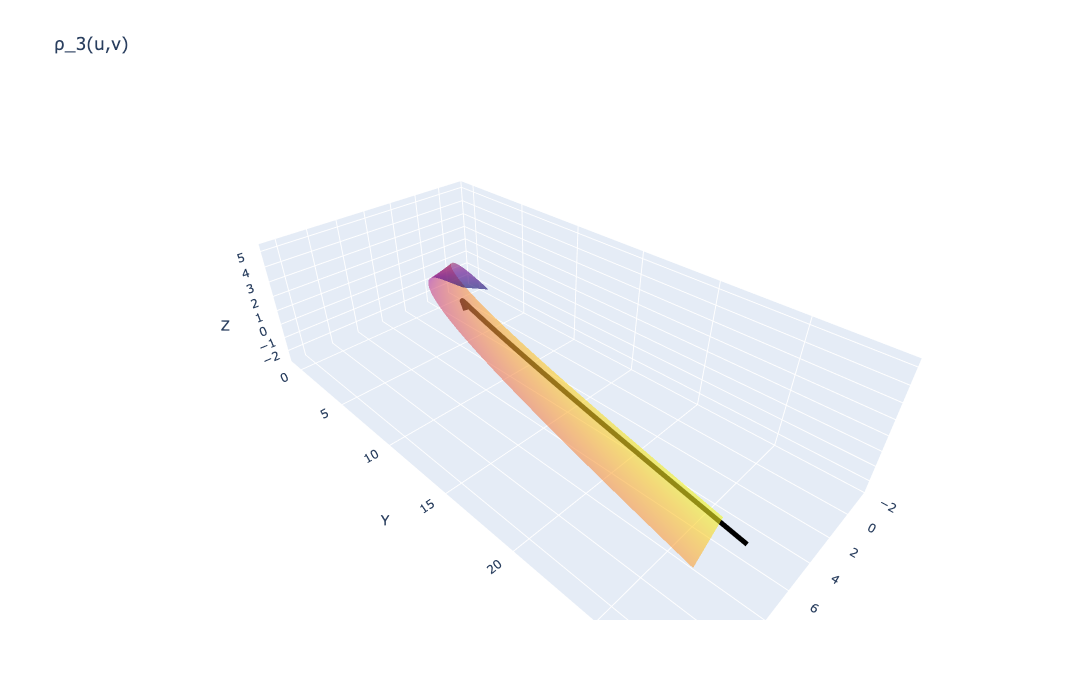

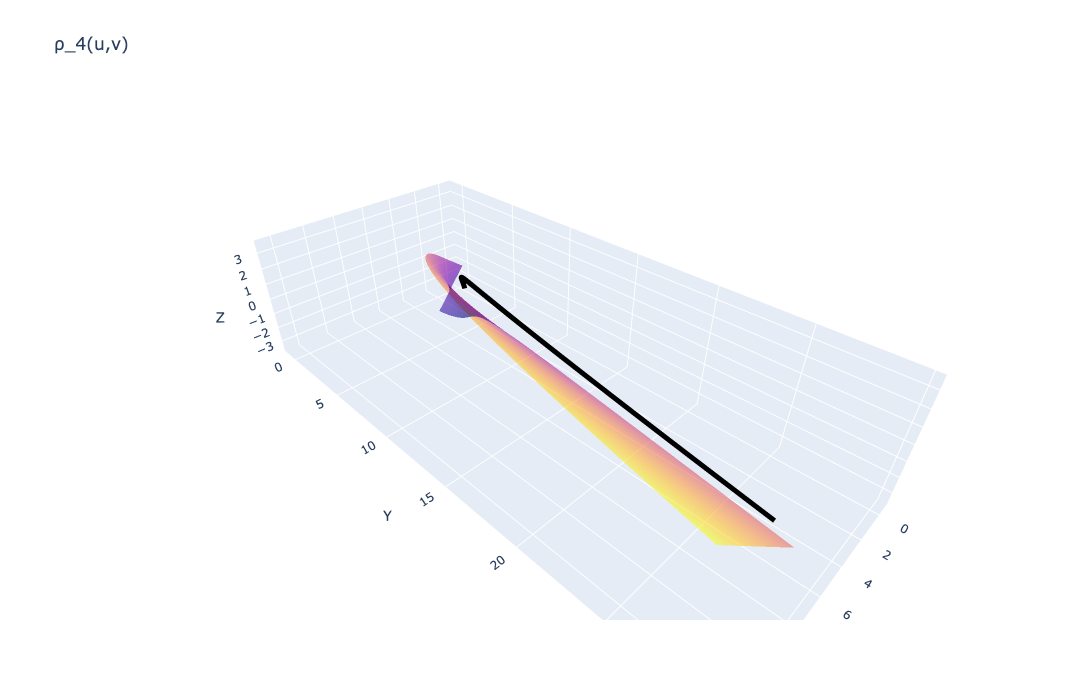

In [10]:
for i, S in enumerate(surfaces, start=1):
    fig = go.Figure()
    add_surface(fig, S, f'ρ_{i}(u,v)')
    add_curve(fig, curve_x, curve_y, curve_z)

    fig.update_layout(
        title=f'ρ_{i}(u,v)',
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z',
            aspectmode='data'
        ),
        width=900,
        height=700
    )
    fig.show()

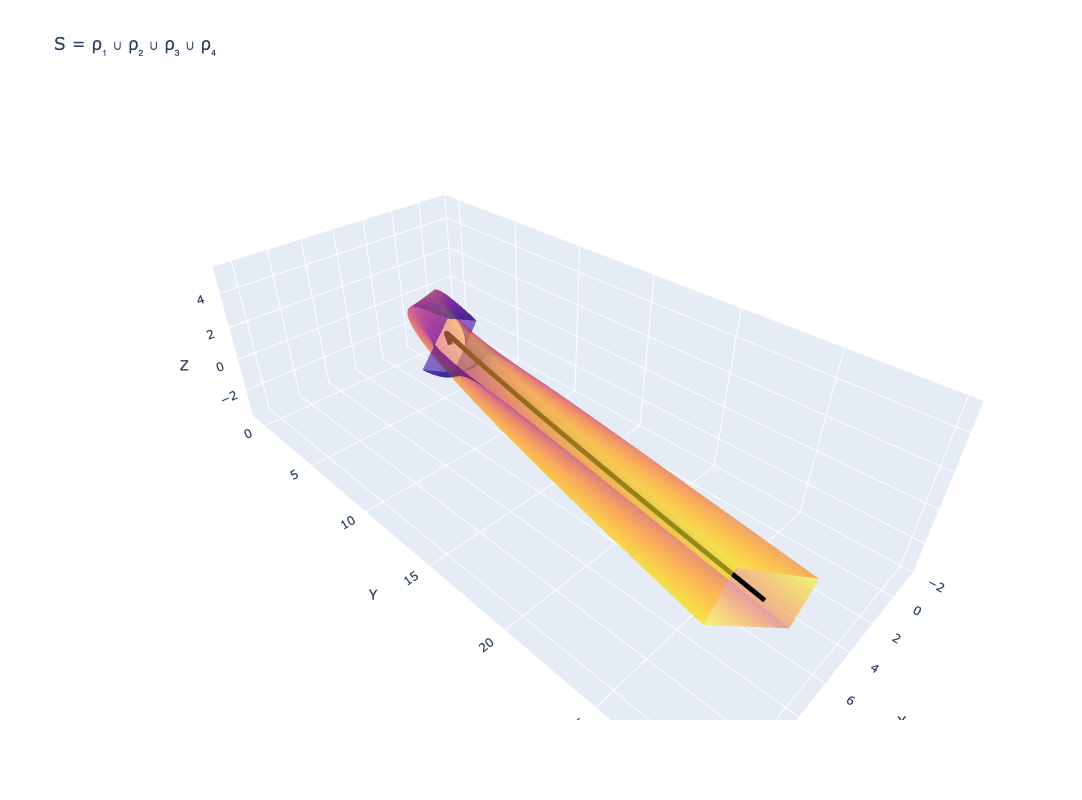

In [11]:
fig_all = go.Figure()

for i, S in enumerate(surfaces, start=1):
    add_surface(fig_all, S, f'ρ_{i}')

add_curve(fig_all, curve_x, curve_y, curve_z)

fig_all.update_layout(
    title='S = ρ₁ ∪ ρ₂ ∪ ρ₃ ∪ ρ₄',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='data'
    ),
    width=1000,
    height=800
)

fig_all.show()
